# MITGCM Transect Heat Flux Analysis

**Purpose**: Code for computing the mean fields and spatial gradients along the CalCOFI line 80 transect.  

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [2]:
%matplotlib inline

Import python libraries

In [3]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import gsw
from geopy.distance import geodesic
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import calendar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from lsf import unweighted_lsf, detrend, compute_amp_phase
import stats
from plotScaleAnalysis import add_freq_marker
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize

Set data analysis parameters

In [4]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/regional/'
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'
PATH_bottom = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'

# Set plotting parameters 
fontsize = 15

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [5]:
#-------------------------------------------------------#
# MITgcm heat flux Data
#-------------------------------------------------------#
filename_flux = PATH + "mitgcm_intermediate_data_heat_salt_flux_dly_map.nc"
nc_flux = Dataset(filename_flux, 'r')

# Extract data variables
lon = nc_flux.variables['lon_trans'][:]
lat = nc_flux.variables['lat_trans'][:]
dist = nc_flux.variables['dist'][:]
time =  num2date(nc_flux.variables['time'][:], nc_flux.variables['time'].units)

Q_net_trans = nc_flux.variables['Q_net_trans'][:]
Q_sw_trans = nc_flux.variables['Q_sw_trans'][:]
S_flux_trans = nc_flux.variables['S_flux_trans'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

#-------------------------------------------------------#
# Ocean Bottom Data
#-------------------------------------------------------#

# Set filename and read in netcdf file
filename = PATH_bottom + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
dist_b = nc.variables['distance'][:]
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [6]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute Heat flux with shortwave flux removed

In [7]:
Q_nonsw_trans = Q_net_trans - Q_sw_trans

Compute the seasonal mean, median, and standard deviation for the wind-stress curl

In [8]:
# Set parameters
seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}

# Define months array for each time step
months = np.array([t.month for t in time.data])

# Removed nearshore points where derivatives are noisy and unreliable
idx_dist = np.where(dist >= 2)[0]
lon_c = lon[idx_dist]
lat_c = lat[idx_dist]
dist_c = dist[idx_dist]

# Set shape of seasonal statistics arrays
ndist = len(dist_c)
ntime = len(time)

# Initialize arrays to hold seasonal statistics
Q_net_mean_season    = np.full((4, ndist), np.nan)
Q_sw_mean_season     = np.full((4, ndist), np.nan)
Q_nonsw_mean_season     = np.full((4, ndist), np.nan)
S_flux_mean_season   = np.full((4, ndist), np.nan)

Q_net_median_season  = np.full((4, ndist), np.nan)
Q_sw_median_season   = np.full((4, ndist), np.nan)
Q_nonsw_median_season   = np.full((4, ndist), np.nan)
S_flux_median_season = np.full((4, ndist), np.nan)

Q_net_var_season    = np.full((4, ndist), np.nan)
Q_sw_var_season     = np.full((4, ndist), np.nan)
Q_nonsw_var_season     = np.full((4, ndist), np.nan)
S_flux_var_season   = np.full((4, ndist), np.nan)

Q_net_stdm_season    = np.full((4, ndist), np.nan)
Q_sw_stdm_season     = np.full((4, ndist), np.nan)
Q_nonsw_stdm_season     = np.full((4, ndist), np.nan)
S_flux_stdm_season   = np.full((4, ndist), np.nan)

# Set counter 
cn = 0

# Loop through seasons 
for season_name, season_months in seasons.items():

    # Print season name for debugging
    print(f"Processing season: {season_name}")

    # Define season mask 
    season_mask = np.isin(months, season_months)

    # Obtain seasonal subset of data
    Q_net_season    = Q_net_trans[season_mask, :]
    Q_sw_season     = Q_sw_trans[season_mask, :]
    Q_nonsw_season  = Q_nonsw_trans[season_mask, :]
    S_flux_season   = S_flux_trans[season_mask, :]

    # Compute seasonal statistics

    #--- Mean ---# 
    Q_net_mean_season[cn, :]    = np.nanmean(Q_net_season, axis=0)[idx_dist]
    Q_sw_mean_season[cn, :]     = np.nanmean(Q_sw_season, axis=0)[idx_dist]
    Q_nonsw_mean_season[cn, :]     = np.nanmean(Q_nonsw_season, axis=0)[idx_dist]
    S_flux_mean_season[cn, :]   = np.nanmean(S_flux_season, axis=0)[idx_dist]

    #--- Median ---#
    Q_net_median_season[cn, :]  = np.nanmedian(Q_net_season, axis=0)[idx_dist]
    Q_sw_median_season[cn, :]   = np.nanmedian(Q_sw_season, axis=0)[idx_dist]
    Q_nonsw_median_season[cn, :]   = np.nanmedian(Q_nonsw_season, axis=0)[idx_dist]
    S_flux_median_season[cn, :] = np.nanmedian(S_flux_season, axis=0)[idx_dist]

    #--- Variance ---#
    Q_net_var_season[cn, :]    = np.nanvar(Q_net_season, axis=0)[idx_dist]
    Q_sw_var_season[cn, :]     = np.nanvar(Q_sw_season, axis=0)[idx_dist]
    Q_nonsw_var_season[cn, :]     = np.nanvar(Q_nonsw_season, axis=0)[idx_dist]
    S_flux_var_season[cn, :]   = np.nanvar(S_flux_season, axis=0)[idx_dist]

    #--- Standard Error ---#
    n_samples_season = np.sum(season_mask)
    Q_net_stdm_season[cn, :]    = np.sqrt(Q_net_var_season[cn, :] / n_samples_season)
    Q_sw_stdm_season[cn, :]     = np.sqrt(Q_sw_var_season[cn, :] / n_samples_season)
    Q_nonsw_stdm_season[cn, :]     = np.sqrt(Q_nonsw_var_season[cn, :] / n_samples_season)
    S_flux_stdm_season[cn, :]   = np.sqrt(S_flux_var_season[cn, :] / n_samples_season)

    # Reinitialize counter 
    cn += 1

# Compute standard deviation 
Q_net_std_season    = np.sqrt(Q_net_var_season)
Q_sw_std_season     = np.sqrt(Q_sw_var_season)
Q_nonsw_std_season     = np.sqrt(Q_nonsw_var_season)
S_flux_std_season   = np.sqrt(S_flux_var_season)

# Compute mean, median, variance, and standard error of the mean and variance for the entire time series (all seasons combined)
Q_net_mean_all   = np.nanmean(Q_net_trans, axis=0)[idx_dist]
Q_sw_mean_all    = np.nanmean(Q_sw_trans, axis=0)[idx_dist]
Q_nonsw_mean_all    = np.nanmean(Q_nonsw_trans, axis=0)[idx_dist]
S_flux_mean_all  = np.nanmean(S_flux_trans, axis=0)[idx_dist]

Q_net_median_all   = np.nanmedian(Q_net_trans, axis=0)[idx_dist]
Q_sw_median_all    = np.nanmedian(Q_sw_trans, axis=0)[idx_dist]
Q_nonsw_median_all    = np.nanmedian(Q_nonsw_trans, axis=0)[idx_dist]
S_flux_median_all  = np.nanmedian(S_flux_trans, axis=0)[idx_dist]

Q_net_var_all     = np.nanvar(Q_net_trans, axis=0)[idx_dist]
Q_sw_var_all     = np.nanvar(Q_sw_trans, axis=0)[idx_dist]  
Q_nonsw_var_all     = np.nanvar(Q_nonsw_trans, axis=0)[idx_dist]  
S_flux_var_all   = np.nanvar(S_flux_trans, axis=0)[idx_dist]

# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Set parameters 
lag = ntime 
estimator = 'biased'
norm = 0
T = time_elapsed[-1] - time_elapsed[0] # Units: seconds

# Initialize array
decor_time_Q_net   = np.full((ndist), np.nan)
decor_time_Q_nonsw = np.full((ndist), np.nan)

# Loop through distance offshore
for idist in range(0,ndist):

    # Extract time series at the ith distance offshore
    tmp_Q_net   = Q_net_trans[:, idist]
    tmp_Q_nonsw = Q_nonsw_trans[:, idist]
    
    # Detrend data record 
    tmp_Q_net_dt = detrend(tmp_Q_net, time_elapsed, mean = 0)
    tmp_Q_nonsw_dt = detrend(tmp_Q_nonsw, time_elapsed, mean = 0)

    # Compute autocorrelation and decorrelation scale 
    autocorr_Q_net, _, _, _, time_lag_Q_net, _ = compute_autocorr_optimize(tmp_Q_net_dt, time_elapsed, lag, estimator, norm)
    autocorr_Q_nonsw, _, _, _, time_lag_Q_nonsw, _ = compute_autocorr_optimize(tmp_Q_nonsw_dt, time_elapsed, lag, estimator, norm)

    # Compute the decorrelation scale
    decor_time_Q_net[idist] = compute_decor_scale_optimize(autocorr_Q_net,time_lag_Q_net,T,'unbiased',0) # Units: seconds
    decor_time_Q_nonsw[idist] = compute_decor_scale_optimize(autocorr_Q_nonsw,time_lag_Q_nonsw,T,'unbiased',0) # Units: seconds

#--- Compute the number of effectve samples ---# 
T_days = T / 86400 

# Convert decorrelation time from seconds to days
decor_time_Q_net_days = decor_time_Q_net / 86400 
decor_time_Q_nonsw_days = decor_time_Q_nonsw / 86400 

# Compute N_eff
N_eff_Q_net   = np.minimum(T_days / decor_time_Q_net_days, ntime)
N_eff_Q_nonsw = np.minimum(T_days / decor_time_Q_nonsw_days, ntime)

# Compute standard error of the mean and variance for the entire time series (all seasons combined)
Q_net_stdm_all      = np.sqrt(Q_net_var_all / N_eff_Q_net)
Q_sw_stdm_all       = np.sqrt(Q_sw_var_all / ntime)
Q_nonsw_stdm_all    = np.sqrt(Q_nonsw_var_all / N_eff_Q_nonsw)
S_flux_stdm_all     = np.sqrt(S_flux_var_all / ntime)

Q_net_stdv_all      = Q_net_var_all * np.sqrt(2/(N_eff_Q_net-1))
Q_sw_stdv_all      = Q_sw_var_all * np.sqrt(2/(ntime-1))
Q_nonsw_stdv_all      = Q_nonsw_var_all * np.sqrt(2/(N_eff_Q_nonsw-1))
S_flux_stdv_all  = S_flux_var_all * np.sqrt(2/(ntime-1))

Processing season: DJF
Processing season: MAM
Processing season: JJA
Processing season: SON


/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Plot the seasonal statistics for $Q_{net}$ 

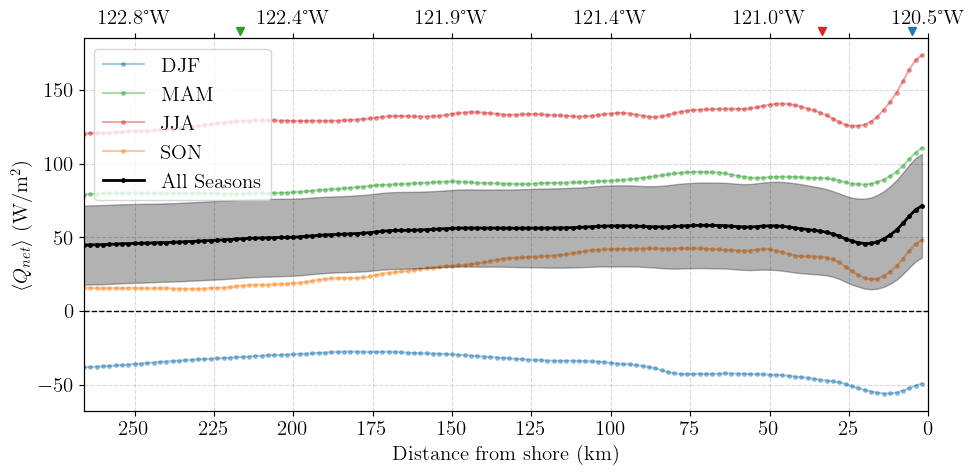

In [9]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the zero line 
ax.axhline(0, color='k', linestyle='--', linewidth=1)

# Plot the mean Q_net for each season
ax.plot(dist_c, Q_net_mean_season[0,:], '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_mean_season[1,:], '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_mean_season[2,:], '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_mean_season[3,:], '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_mean_all, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_c, Q_net_mean_all - Q_net_stdm_all, Q_net_mean_all + Q_net_stdm_all, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle Q_{net} \rangle$ (W/m$^2$)')
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
#ax.set_ylim(30, 80)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

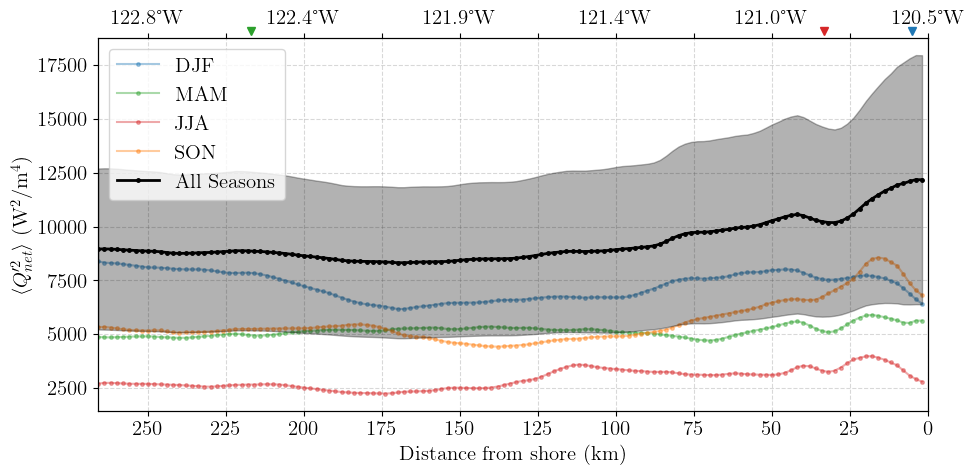

In [10]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean wind stress curl for each season
ax.plot(dist_c, Q_net_var_season[0,:], '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_var_season[1,:], '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_var_season[2,:], '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_var_season[3,:], '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_net_var_all, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax.fill_between(dist_c, Q_net_var_all - Q_net_stdv_all, Q_net_var_all + Q_net_stdv_all, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r"$\langle Q_{net}'^2 \rangle$ (W$^2$/m$^4$)")
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
#ax.set_ylim(0, 4)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Plot box and wisket plots along the transect for each wind stress variable

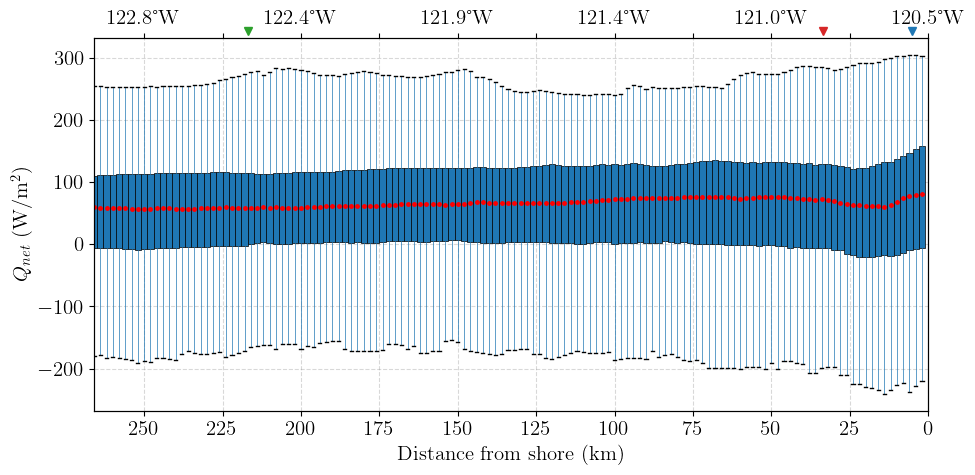

In [11]:
# Set plotting parameters
Q_net_list = [Q_net_trans[:,i] for i in range(Q_net_trans.shape[1]) if dist[i] >= 2]

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot box plot 
ax.boxplot(Q_net_list, positions=dist_c, vert=True, patch_artist=True, widths=2, showfliers=False, manage_ticks=False,  
            medianprops=dict(linestyle='none'), 
            boxprops=dict(color='k',          
                          linewidth=0.5,          
                          linestyle='--'), 
            whiskerprops=dict(linewidth=0.5, 
                              color='#1f77b4', 
                              linestyle='-'))

# Plot median wind-stress curl 
ax.plot(dist_c,Q_net_median_all,'.', color='red', markerfacecolor='red', markersize=5, label='Median')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$Q_{net}$ (W/m$^2$)')
ax.set_xticks(np.arange(0,250+25,25))
ax.set_xlim(0,dist_c[-1])
#ax.set_ylim(-3, 7)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Plot the seasonal statistics for $Q_{nonSW}$ 

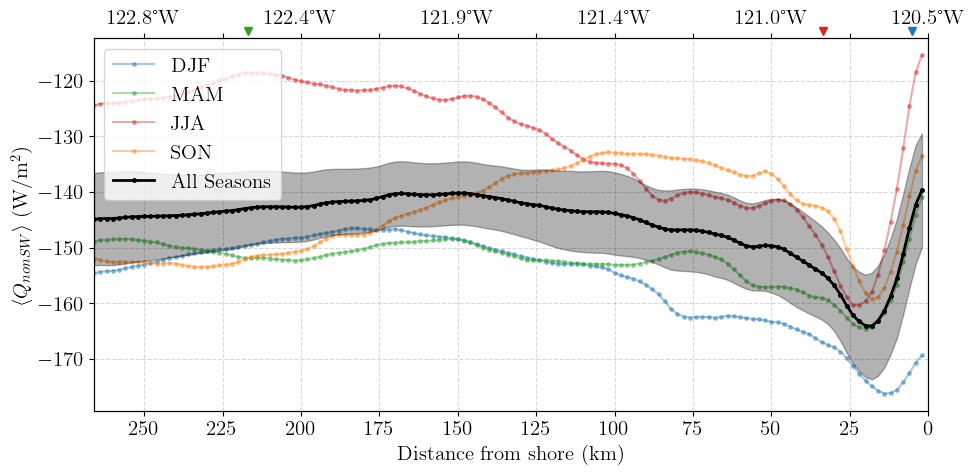

In [12]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean Q_net for each season
ax.plot(dist_c, Q_nonsw_mean_season[0,:], '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_mean_season[1,:], '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_mean_season[2,:], '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_mean_season[3,:], '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_mean_all, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_c, Q_nonsw_mean_all - Q_nonsw_stdm_all, Q_nonsw_mean_all + Q_nonsw_stdm_all, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle Q_{nonSW} \rangle$ (W/m$^2$)')
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
#ax.set_ylim(30, 80)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

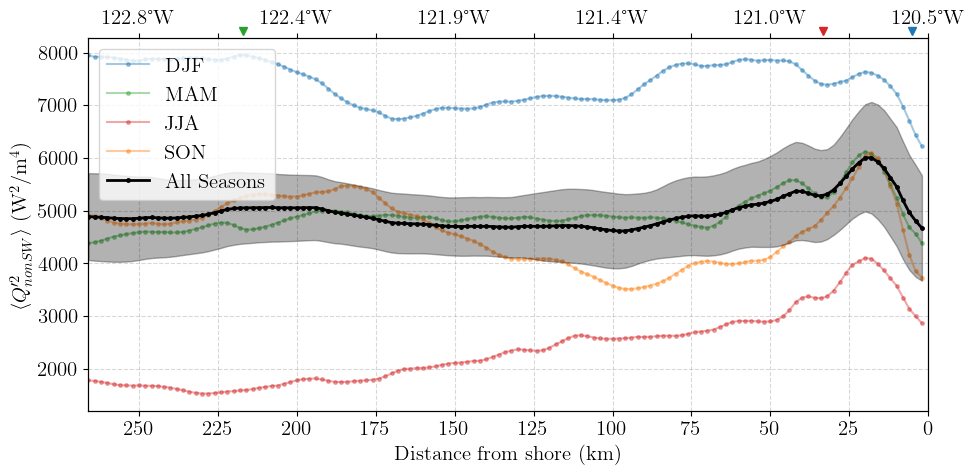

In [13]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean wind stress curl for each season
ax.plot(dist_c, Q_nonsw_var_season[0,:], '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_var_season[1,:], '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_var_season[2,:], '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_var_season[3,:], '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, Q_nonsw_var_all, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax.fill_between(dist_c, Q_nonsw_var_all - Q_nonsw_stdv_all, Q_nonsw_var_all + Q_nonsw_stdv_all, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r"$\langle Q_{nonSW}'^2 \rangle$ (W$^2$/m$^4$)")
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
#ax.set_ylim(0, 4)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Plot box and wisket plots along the transect for each wind stress variable

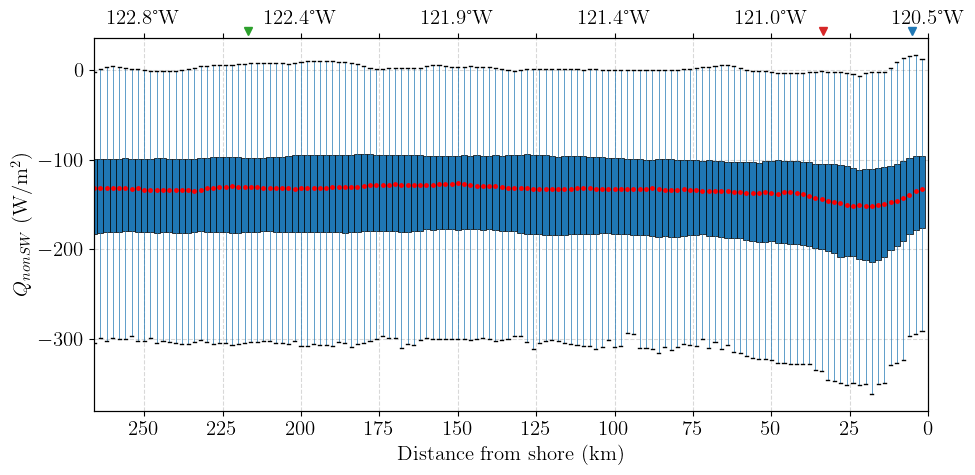

In [14]:
# Set plotting parameters
Q_nonsw_list = [Q_nonsw_trans[:,i] for i in range(Q_nonsw_trans.shape[1]) if dist[i] >= 2]

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot box plot 
ax.boxplot(Q_nonsw_list, positions=dist_c, vert=True, patch_artist=True, widths=2, showfliers=False, manage_ticks=False,  
            medianprops=dict(linestyle='none'), 
            boxprops=dict(color='k',          
                          linewidth=0.5,          
                          linestyle='--'), 
            whiskerprops=dict(linewidth=0.5, 
                              color='#1f77b4', 
                              linestyle='-'))

# Plot median wind-stress curl 
ax.plot(dist_c,Q_nonsw_median_all,'.', color='red', markerfacecolor='red', markersize=5, label='Median')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$Q_{nonSW}$ (W/m$^2$)')
ax.set_xticks(np.arange(0,250+25,25))
ax.set_xlim(0,dist_c[-1])
#ax.set_ylim(-3, 7)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

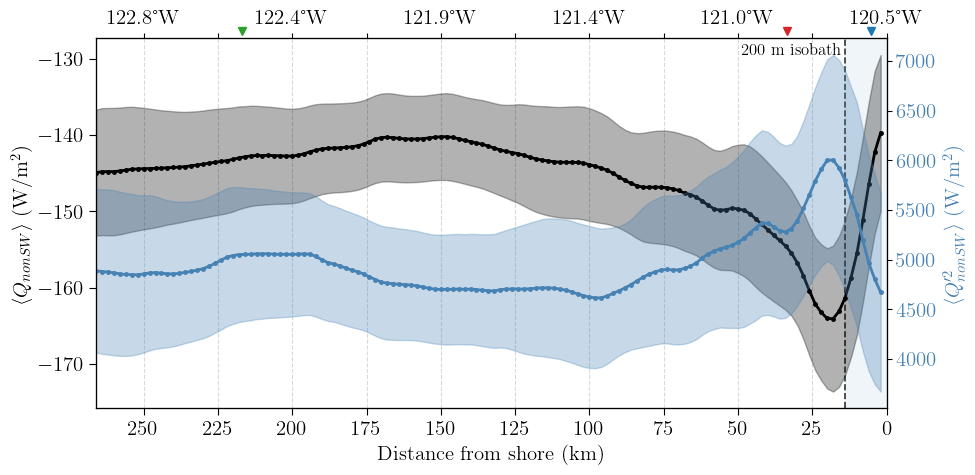

In [29]:
# Set the index of the coastline (where bottom depth is closest to 200 m)
idx_coast = np.argmin(np.abs(np.abs(bottom_depth) - 200))

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

# Twin the axis for variance 
ax_twin = ax.twinx()

#--- Mean Q_nonSW ---# 

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 35, 0.985, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=12, color='k', rotation=0)

# Plot the mean Q_net for each season
ax.plot(dist_c, Q_nonsw_mean_all, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_c, Q_nonsw_mean_all - Q_nonsw_stdm_all, Q_nonsw_mean_all + Q_nonsw_stdm_all, color='k', alpha=0.3, zorder=3)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle Q_{nonSW} \rangle$ (W/m$^2$)')
ax.set_xticks(np.arange(0, 250+25, 25))
ax.set_xlim(0, dist_c[-1])
ax.invert_xaxis()
ax.grid(axis= 'x', linestyle='--', alpha=0.3, color='grey')
ax.tick_params(which='both', direction='out', top=True, right=False, left=True, bottom=True, length=5)

#--- Variance Q_nonSW ---# 

# Plot the mean wind stress curl for each season
ax_twin.plot(dist_c, Q_nonsw_var_all, '.-', color='steelblue', linewidth=2, label='All Seasons', markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax_twin.fill_between(dist_c, Q_nonsw_var_all - Q_nonsw_stdv_all, Q_nonsw_var_all + Q_nonsw_stdv_all, color='steelblue', alpha=0.3, zorder=3)

# Set axis attributes
ax_twin.set_ylabel(r"$\langle Q_{nonSW}'^2 \rangle$ (W/m$^2$)", color='steelblue')
ax_twin.tick_params(axis='y', labelcolor='steelblue', labelsize=fontsize)

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Save intermediate data 

In [31]:
#--- Heat Flux statistics ---# 

# Check if file exists, then delete it
file_path = PATH + "/mitgcm_transect_heat_flux_stats_CalCOFI_line80.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal statistic of surface heat flux from the MITgcm model out of along CalCOFI line 80.',
    'source': 'MITgcm model data from SWOT_MARA_RUN4_LY',
    'coordinates units': 'km'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
            Q_nonsw_trans        = Q_nonsw_trans, 
            Q_nonsw_mean_all     = Q_nonsw_mean_all,
            Q_nonsw_stdm_all     = Q_nonsw_stdm_all, 
            Q_nonsw_var_all      = Q_nonsw_var_all,  
            Q_nonsw_stdv_all     = Q_nonsw_stdv_all,     
            dist_c               = dist_c,
            lon                  = lon_c,
            lat                  = lat_c, 
            time                 = time, 
            metadata             = metadata
            )